# Support Vector Machine (SVM)

O Support Vector Machine (SVM) é um dos algoritmos de Machine Learning mais robustos e populares para Classificação e Regressão. Ele é um modelo de aprendizado supervisionado, o que significa que opera em um conjunto de dados com rótulos ou alvos conhecidos (com a variável target $y$).

Sua principal função é encontrar a fronteira de decisão ideal (o hiperplano) que separa as diferentes classes de dados com a maior margem de segurança possível, de acordo com as características apresentadas.

## Nota Histórica

Embora hoje o Deep Learning roube a cena, o SVM tem raízes que remontam à teoria estatística soviética da década de 1960, originando-se de forma independente dos modelos de redes neurais tradicionais. O algoritmo linear base foi inicialmente proposto por Vladimir Vapnik e Alexey Chervonenkis em 1963, no Instituto de Ciências de Controle de Moscou.

Paralelamente, os estudos evoluíram até que, em 1992, Bernhard Boser, Isabelle Guyon e Vapnik introduziram o famoso "Kernel Trick" (Truque do Kernel). A versão padrão iterativa e robusta que usamos hoje (com margens suaves ou *Soft Margins* para lidar com classificações erradas) foi publicada por Corinna Cortes e Vapnik em 1995. É um exemplo clássico de como a matemática elegante e a física estatística sobrevivem ao teste do tempo, moldando a inteligência artificial moderna.

## Vantagens e Desvantagens

Como qualquer algoritmo de Machine Learning, o SVM não é uma "bala de prata". Entender onde ele brilha e onde ele falha é fundamental para o trabalho de um Cientista de Dados.

**Vantagens:**

* **Eficácia em Alta Dimensionalidade:** É excepcionalmente poderoso em espaços onde o número de dimensões (features) excede o número de amostras.
* **Eficiência de Memória:** Após o treinamento, o modelo constrói a fronteira usando apenas os pontos críticos mais próximos da divisão (os Vetores de Suporte), descartando o restante dos dados.
* **Versatilidade Geométrica (Kernel Trick):** Através de funções matemáticas, o algoritmo consegue traçar fronteiras curvas e complexas de forma implícita, superando o viés de separação puramente linear sem explodir o custo computacional com transformações manuais.
* **Robusto Contra Overfitting:** A natureza do algoritmo em tentar maximizar a distância da margem atua como uma regularização natural, penalizando fronteiras de decisão que ficam complexas demais.

**Desvantagens:**

* **O Problema do Custo Computacional:** Tem complexidade de tempo que cresce de forma quadrática a cúbica (de $\mathcal{O}(n^2)$ a $\mathcal{O}(n^3)$), o que significa que é extremamente lento e não escala bem para conjuntos de dados massivos.
* **Sensibilidade a Ruídos:** Se as classes estiverem muito sobrepostas no espaço ou houver muitos extremos (*outliers*), a otimização da margem pode falhar, exigindo ajustes exaustivos do hiperparâmetro de penalização ($C$).
* **Falta de Transparência Probabilística:** Ao contrário da Regressão Logística, o SVM padrão não retorna nativamente a probabilidade de uma predição estar correta (exigindo cálculos extras pesados, como o escalonamento de Platt).
* **"Caixa Preta" Não Linear:** Quando utilizado com Kernels muito complexos, a lógica exata de uma decisão torna-se opaca, sendo difícil de explicar para partes interessadas (*stakeholders*) não técnicas.

## Principais Casos de Uso

Apesar de suas limitações computacionais em grandes volumes de dados, a robustez matemática do SVM o torna a escolha número um da indústria para as seguintes aplicações práticas:

* **Bioinformática e Genética:** Classificar perfis de expressão gênica e reconhecer sequências de proteínas, cenários onde o número de variáveis (features genéticas) costuma ser infinitamente maior que o número de pacientes (amostras).
* **Física de Altas Energias:** Separar sinais de colisões raras do ruído de fundo (*background*) em aceleradores de partículas, graças à sua capacidade de desenhar fronteiras precisas em múltiplas variáveis cinemáticas.
* **Classificação de Textos (NLP):** Agrupar e categorizar documentos ou analisar sentimentos a partir de vetorizações como TF-IDF, lidando perfeitamente com as matrizes esparsas e de alta dimensionalidade geradas pelos textos.
* **Visão Computacional e Imagens Médicas:** Detectar anomalias em radiografias ou realizar o reconhecimento de caracteres (OCR) em sistemas embarcados que precisam de alta precisão sem depender do peso de uma rede neural profunda.

### 1. Definição Matemática do Problema

Tratamos cada observação como um objeto numérico num espaço multidimensional.

* **Características ($\lambda$):** Suponha que tenhamos $N$ características $\lambda_1, \dots, \lambda_N$. No caso de imagens, cada $\lambda$ representa a intensidade de cinzento de um pixel específico.
* **Alvo (Target $y_i$):** É a classificação desejada (ex: o dígito "5" ou a identidade de um rosto).
* **Vetor de Medida ($\vec{x}_i$):** Após $D$ observações (amostras de treino), seja $\vec{x}_i$ o vetor da $i$-ésima observação dessas características, ou seja:

$$\vec{x}_i = (\lambda_{1}^{(i)}, \dots, \lambda_{N}^{(i)})$$

* **Evento:** O conjunto $(\vec{x}_i, y_i)$ chamamos de **i-ésimo evento**.

---

### 2. O Hiperplano e a Margem (APENAS 2 CATEGORIAS)
O objetivo do algoritmo SVM é encontrar um **hiperplano** de separação num espaço de dimensão $N$ que maximize a distância entre as classes. Então, definimos

$$f(\vec{x}; \vec{w}, b) := \vec{w} \cdot \vec{x} + b.$$

Aqui:
* $\vec{w}$ é o vetor normal ao hiperplano.
* $b$ é o bias (deslocamento, distância entre o hiperplano e a origem).
* Os **Vetores de Suporte** são os vetores $\vec{x}_i$ que se encontram exatamente na fronteira da margem.

Também:
* $y_i = 1$ se a observação $i$ pertence à classe $+1$.
* $y_i = -1$ se a observação $i$ pertence à classe $-1$.

Os pesos e viés $(\vec{w}, b)$ são obtidos minimizando **Hinge Loss (Perda de Dobradiça)**:

$$J(\vec{w}, b) = \underbrace{\frac{1}{2} ||\vec{w}||^2_{_2}}_{\textrm{regularização}} + \eta \left[\frac{1}{D}\sum_{i= 1}^{D} \textrm{max}\left(0; \, 1 - f(\vec{x}_i; \vec{w}, b) y_i \right)\right].$$

* Após minimizada, separamos em duas classes: $f(\vec{x}_i; \vec{w}, b) > 0$ e $f(\vec{x}_i; \vec{w}, b) < 0$.

A equação do hiperplano é:

$$\vec{w} \cdot \vec{x} + b = 0.$$

Definimos as margens de segurança como $\vec{w} \cdot \vec{x} + b = y_i.$

* $\vec{w} \cdot \vec{x} + b = + 1.$

* $\vec{w} \cdot \vec{x} + b = - 1.$

O termo de regularização maximiza a distância máxima entre o hiperplano e as margens de segurança.

## Exemplo

Primeiramente, geraremos pseudodados sintéticos para facilitar a análise. Os pseudodados consistirão em pontos aleatórios distribuídos dentro de duas elipses, definidas pela seguinte desigualdade:

$$
\frac{(x-x_0)^2}{a^2} + \frac{(y-y_0)^2}{b^2} \leq 1.
$$

Usando Python, vamos gerar pares de coordenadas $(x, y)$, em que $x \in [x_0 - a, x_0 + a]$ é um número aleatório e $y$ é um número aleatório limitado por:

$$
-b\sqrt{1 -\frac{(x-x_0)^2}{a^2}} + y_0 \leq y \leq b\sqrt{1 -\frac{(x-x_0)^2}{a^2}} + y_0.
$$

**Ideia:** o objetivo é dar as coordenadas cartesianas de um ponto gerado aleatoriamente, $\vec{x} := (\lambda_1, \lambda_2):= (x, y)$, sem a "label" de qual elipse ele pertence. O algoritmo deve ser capaz de separar os pontos.

Para esse problema, temos $N=2$ características, a saber, as coordenadas cartesianas $(x, y)$, e o número $d$ de dados é o número de pontos aleatórios gerados.


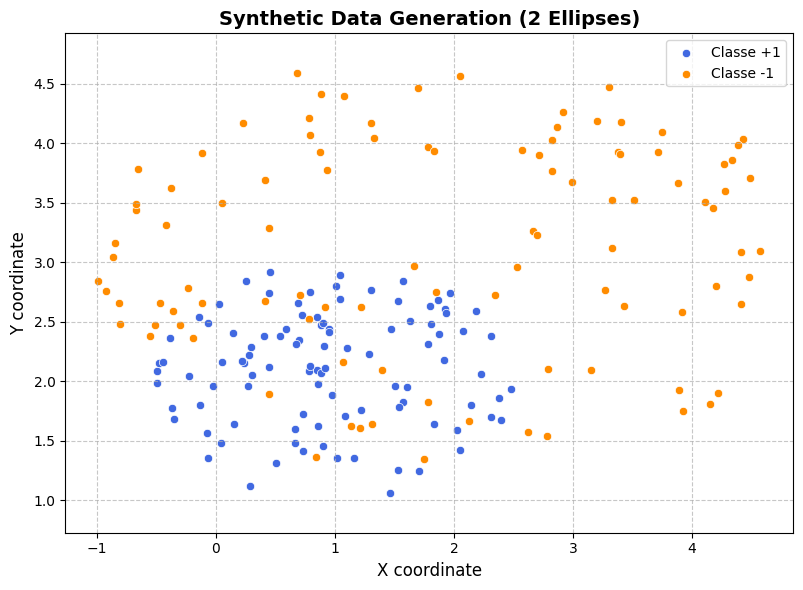

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

#-------------------------------------
# We have N = 2 characteristics, namely, x and y coordinate
N = 2

#------------------------------------------------------------------
# PSEUDO-DATA GENERATION
#------------------------------------------------------------------
# Pseudo-data generation - we generate d_points random numbers in [x0 - a, x0 + a] through an uniform distribution

# Number os random points generated in each elipse
d_1 = 100
d_2 = 100

#Sample number
d = d_1 + d_2

def xy_gen(d_points, x0, y0, a, b):

    x_min = x0 - a
    x_max = x0 + a

    # np.random.uniform(limite_inferior, limite_superior, quantidade)
    x = np.random.uniform(x_min, x_max, d_points)

    y_min = y0 - b*np.sqrt(1.0 - ((x-x0)/a)**2)
    y_max = y0 + b*np.sqrt(1.0 - ((x-x0) /a)**2)

    y = np.random.uniform(y_min, y_max, d_points)

    return (x, y)

#-------------------------------------
# Graph generator

# 1. Generating the pseudo-data for 2 ellipses (Binary Classification)
x1, y1 = xy_gen(d_1, x0=1, y0=2, a=1.5, b=1.0)
c1 = np.full(d_1, 'royalblue')

x2, y2 = xy_gen(d_2, x0=2, y0=3, a=3.0, b=1.8)
c2 = np.full(d_2, 'darkorange')

#-------------------------------------
# We create the X: all points in a single matrix for SVM
x_svm = np.concatenate([x1, x2])
y_svm = np.concatenate([y1, y2])
c_svm = np.concatenate([c1, c2])

# Matriz X com 200 pontos (100 de cada classe)
X = np.column_stack((x_svm, y_svm))

colors_labeled = c_svm.tolist()

# Class labels:
# +1 for the firts ellipse (Azul)
# -1 for the second ellipse (Laranja)
y_labels = np.array([1] * len(x1) + [-1] * len(x2))

#-------------------------------------------------------------------
# FIGURES
#-------------------------------------------------------------------

# 2. Figure configuration
plt.figure(figsize=(8, 6))

# 3. Plot. The scatter don't join the points with a line as the plot.
plt.scatter(x1, y1, color=c1[0], alpha=1, edgecolors='w', linewidth=0.5, label='Classe +1')
plt.scatter(x2, y2, color=c2[0], alpha=1, edgecolors='w', linewidth=0.5, label='Classe -1')

# 4. Labels
plt.title('Synthetic Data Generation (2 Ellipses)', fontsize=14, fontweight='bold')
plt.xlabel('X coordinate', fontsize=12)
plt.ylabel('Y coordinate', fontsize=12)

# Axis x and y have the same scale
plt.axis('equal')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 5. Save and show the graph
plt.tight_layout()
plt.savefig('pseudo_data_ellipses.png', dpi=300)
plt.show()


## O Algoritmo na Prática (Otimização via Gradiente Descendente)

Diferente do K-Means, que baseia suas iterações no cálculo de médias geométricas simples, o treinamento de um SVM linear exige a minimização contínua da função de custo (Hinge Loss) que definimos na formulação matemática. Para realizar essa minimização "na mão", utilizamos o método de otimização conhecido como **Gradiente Descendente Estocástico (SGD - Stochastic Gradient Descent)**.

A ideia é calcular as derivadas parciais da função de custo em relação aos pesos $\vec{w}$ e ao bias $b$. Para cada evento (ponto) $\vec{x}_i$ e seu rótulo $y_i$, verificamos se o ponto está do lado correto e fora da margem de segurança.

Matematicamente, testamos a condição:
$$\text{margem} = y_i (\vec{w} \cdot \vec{x}_i + b)$$

**Cenário 1: Classificação Correta e Fora da Margem**
Se a margem for $\geq 1$, a perda (Hinge Loss) é zero. O modelo só precisa se preocupar em maximizar a margem (o termo de regularização). A atualização dos pesos, ponderada pela taxa de aprendizado $\alpha$, é:
$$\vec{w} \leftarrow \vec{w} - \alpha (\lambda \vec{w})$$
O bias $b$ não é alterado.

**Cenário 2: Erro ou Invasão da Margem**
Se a margem for $< 1$, o ponto foi classificado incorretamente ou está perigosamente perto da fronteira. A penalidade é ativada e os gradientes "puxam" o hiperplano na direção correta para consertar o erro:
$$\vec{w} \leftarrow \vec{w} - \alpha (\lambda \vec{w} - y_i \vec{x}_i)$$
$$b \leftarrow b + \alpha y_i$$

Abaixo, implementamos essa lógica vetorial em Python puro, iterando sobre o conjunto de dados embaralhado por um número definido de épocas:

Pesos finais: w = [-0.31229696 -1.32662591]
Bias final: b = 4.2900
Loss final: 0.5387


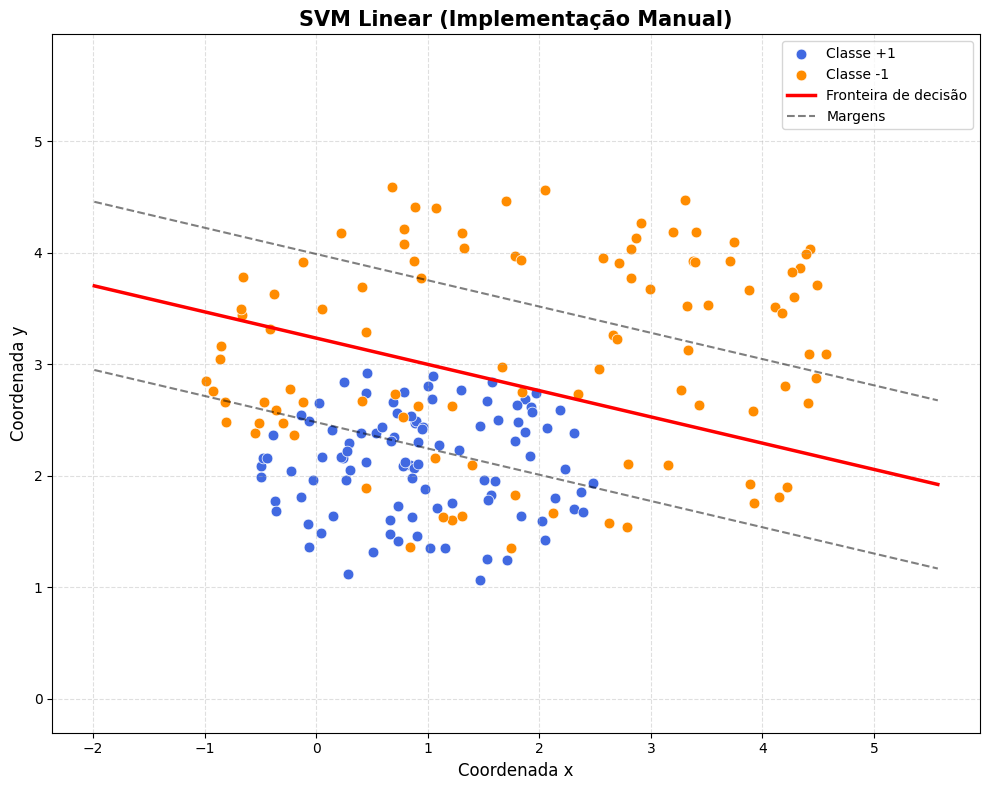

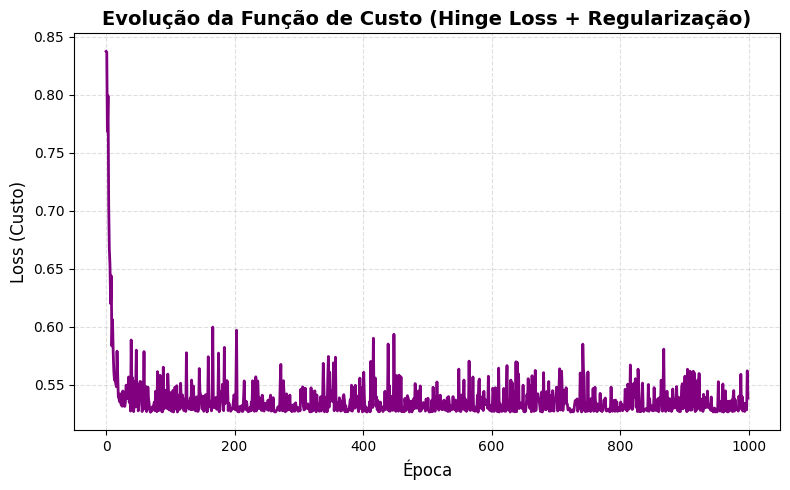

In [15]:
# ============================================================
# 2. SVM COST FUNCTION
# ============================================================
def svm_cost(X, y, w, b, lambda_reg=0.01):
    """
    We calculate the cost function of the linear SVM:

        J(w,b) = (lambda/2) ||w||^2 + média da hinge loss

    onde:
        hinge_i = max(0, 1 - y_i (w·x_i + b))
    """
    scores = np.dot(X, w) + b
    margins = y * scores
    hinge_losses = np.maximum(0.0, 1.0 - margins)

    regularization = 0.5 * lambda_reg * np.dot(w, w)
    data_loss = np.mean(hinge_losses)

    return regularization + data_loss


# ============================================================
# 3. TRAINS OF SVM LINEAR
# ============================================================
w = np.zeros(2)
b = 0.0

# Hiperparams
learning_rate = 0.01
epochs = 1000
lambda_reg = 0.01

loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y_labels[indices]

    # SGD - Stochastic Gradient Descent
    for x_i, y_i in zip(X_shuffled, y_shuffled):
        margin = y_i * (np.dot(w, x_i) + b)

        if margin >= 1:
            w = w - learning_rate * (lambda_reg * w)
        else:
            w = w - learning_rate * (lambda_reg * w - y_i * x_i)
            b = b + learning_rate * y_i

    current_loss = svm_cost(X, y_labels, w, b, lambda_reg=lambda_reg)
    loss_history.append(current_loss)

print(f"Pesos finais: w = {w}")
print(f"Bias final: b = {b:.4f}")
print(f"Loss final: {loss_history[-1]:.4f}")

# ============================================================
# 4. FRONTIER OF DECISION
# ============================================================
plt.figure(figsize=(10, 8))

# Points of class +1
plt.scatter(
    x1, y1,
    color="royalblue",
    edgecolors="w",
    linewidth=0.5,
    s=60,
    label="Classe +1"
)

# Points of class -1
plt.scatter(
    x2, y2,
    color="darkorange",
    edgecolors="w",
    linewidth=0.5,
    s=60,
    label="Classe -1"
)

x_plot = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 300)

# Frontier: w0*x + w1*y + b = 0
# y = -(w0*x + b)/w1
if abs(w[1]) > 1e-12:
    y_decision = -(w[0] * x_plot + b) / w[1]
    plt.plot(
        x_plot, y_decision,
        color="red",
        linewidth=2.5,
        label="Fronteira de decisão"
    )

    # w·x + b = +1 e w·x + b = -1
    y_margin_pos = (1.0 - w[0] * x_plot - b) / w[1]
    y_margin_neg = (-1.0 - w[0] * x_plot - b) / w[1]

    plt.plot(x_plot, y_margin_pos, "k--", alpha=0.5, label="Margens")
    plt.plot(x_plot, y_margin_neg, "k--", alpha=0.5)

plt.title("SVM Linear (Implementação Manual)", fontsize=15, fontweight="bold")
plt.xlabel("Coordenada x", fontsize=12)
plt.ylabel("Coordenada y", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.axis("equal")
plt.tight_layout()

plt.savefig('svm_decision_boundary.png', dpi=300)

# ============================================================
# 5. COST FUNCTION EVOLUTION
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='purple', linewidth=2)
plt.title("Evolução da Função de Custo (Hinge Loss + Regularização)", fontsize=14, fontweight="bold")
plt.xlabel("Época", fontsize=12)
plt.ylabel("Loss (Custo)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# O Hiperplano e a Margem (MAIS DE 2 CATEGORIAS - Estratégia OvR)

Para problemas com $K$ categorias, o objetivo do algoritmo SVM é encontrar um conjunto de $K$ **hiperplanos** de separação. A estratégia mais comum é a **One-vs-Rest (OvR)**, onde cada classe é comparada contra todas as outras.

Definimos uma função de decisão para cada classe $k \in \{1, \dots, K\}$:

$$f_k(\vec{x}; \vec{w}_k, b_k) := \vec{w}_k \cdot \vec{x} + b_k$$

Aqui:
* $\vec{w}_k$ é o vetor normal ao $k$-ésimo hiperplano.
* $b_k$ é o bias (deslocamento) do $k$-ésimo hiperplano.
* Os **Vetores de Suporte** são as observações $\vec{x}_i$ que definem a margem de separação entre a classe $k$ e as restantes.

Para cada hiperplano $k$, os pesos e viés $(\vec{w}_k, b_k)$ são obtidos minimizando a **Hinge Loss** específica para essa classe:

$$J(\vec{w}_k, b_k) = \frac{1}{2} ||\vec{w}_k||^2_{_2} + \eta \left[\frac{1}{D}\sum_{i=1}^D \text{max}\left(0; \, 1 - f_k(\vec{x}_i; \vec{w}_k, b_k) y_i^{(k)} \right)\right],$$

em que:
* $y_i^{(k)} = 1$ se a observação $i$ pertence à classe $k$.
* $y_i^{(k)} = -1$ se a observação $i$ pertence a qualquer outra classe.

#### Decisão Final
Após a minimização de todos os $K$ problemas, a classificação de um novo vetor $\vec{x}$ é dada pela classe que maximiza a função de decisão:

$$\hat{y} = \text{argmax}_{k \in \{1, \dots, K\}} (\vec{w}_k \cdot \vec{x} + b_k)$$

$$\color{red}{QUAL}\, \color{red}{CATEGORIA}\,\, k\,\, \color{red}{PRODUZIU}\, \color{red}{O}\, \color{red}{MAIOR} \quad f_k(\vec{x})\,?$$

As equações dos hiperplanos de separação são:
$$\vec{w}_k \cdot \vec{x} + b_k = 0, \quad \text{para } k = 1, \dots, K.$$

---------------------------------------------------------------

## Aplicação: Classificação de Imagens

Para demonstrar a eficácia da estratégia OvR em um cenário de alta dimensionalidade, aplicaremos o SVM no clássico dataset MNIST.

### Dataset MNIST (Modified National Institute of Standards and Technology)

O **MNIST** é o dataset padrão para validar algoritmos de classificação de imagens.

* **Conteúdo:** 70.000 imagens de dígitos manuscritos (0 a 9).
* **Formato:** Matrizes de $28 \times 28$ píxeis.
* **Vetorização:** Cada imagem é "achatada" num vetor $\vec{x}_i$ de **784 dimensões**.
* **Valores:** Intensidade de cinzento entre **0** (branco) e **255** (preto).

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset
Loading files...
Examples from the original dataset (28x28 pixels):


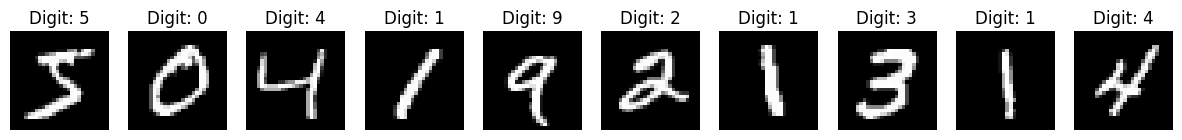

In [16]:
import os
import gzip
import kagglehub

# -------------------------------------------------------------------
# 1. DATASET DOWNLOAD
# -------------------------------------------------------------------
# Download the latest version of the MNIST dataset
path = kagglehub.dataset_download("hojjatk/mnist-dataset")

print("Path to dataset files:", path)

# -------------------------------------------------------------------
# 2. AUTOMATIC FILE SEARCH
# -------------------------------------------------------------------
files = []
for root, dirs, filenames in os.walk(path):
    for filename in filenames:
        files.append(os.path.join(root, filename))

X_train_path = next(f for f in files if 'train-images' in f)
y_train_path = next(f for f in files if 'train-labels' in f)
X_test_path = next(f for f in files if 't10k-images' in f)
y_test_path = next(f for f in files if 't10k-labels' in f)

# -------------------------------------------------------------------
# SMART LOADING FUNCTIONS
# -------------------------------------------------------------------
def smart_load_images(filename):
    """ Tries to open as GZIP, falls back to standard binary if it fails """
    try:
        with gzip.open(filename, 'rb') as f:
            content = f.read()
    except Exception:
        with open(filename, 'rb') as f:
            content = f.read()

    # Offset 16 is standard for IDX image files
    data = np.frombuffer(content, np.uint8, offset=16)
    return data.reshape(-1, 784)

def smart_load_labels(filename):
    """ Tries to open as GZIP, falls back to standard binary if it fails """
    try:
        with gzip.open(filename, 'rb') as f:
            content = f.read()
    except Exception:
        with open(filename, 'rb') as f:
            content = f.read()

    # Offset 8 is standard for IDX label files
    return np.frombuffer(content, np.uint8, offset=8)

# -------------------------------------------------------------------
# 3. LOADING DATA
# -------------------------------------------------------------------
print("Loading files...")
X_train_full = smart_load_images(X_train_path)
y_train_full = smart_load_labels(y_train_path)
X_test_full = smart_load_images(X_test_path)
y_test_full = smart_load_labels(y_test_path)

# Function to visualize the digits
def visualize_samples(images, labels, n_samples=10):
    plt.figure(figsize=(15, 3))
    for i in range(n_samples):
        plt.subplot(1, n_samples, i + 1)

        # Reshape the 784 1D array back to 28x28 for image visualization
        image_2d = images[i].reshape(28, 28)

        plt.imshow(image_2d, cmap='gray')
        plt.title(f"Digit: {labels[i]}")
        plt.axis('off')
    plt.show()

# Visualize before processing and training
print("Examples from the original dataset (28x28 pixels):")
visualize_samples(X_train_full, y_train_full, n_samples=10)

* Temos que $y_i = \{0, 1,..., 9\}$;

* Cada imagem é uma matriz de $28 \times 28$ pixels. Para o SVM, "achatamos" (flatten) essa matriz num vetor de 784 características ($N=784$);

* Cada pixel tem um valor que varia geralmente entre 0 e 255 (ou entre 0 e 1, após normalização).

* 0: Representa o fundo (preto).

* 255: Representa a parte escrita do dígito (branco puro).

* Valores intermédios: Representam tons de cinzento (as bordas do traçado).

### Métricas

* **Precision**: De todos os que o modelo disse ser o dígito X, quantos eram realmente X?

Exemplo no Dígito 1 (0.97): Quando o modelo diz que uma imagem é o número 1, ele acerta 97% das vezes. Ele é muito "certeiro" aqui.

* **Recall**: De todos os dígitos X que realmente existiam no teste, quantos o modelo conseguiu encontrar?

Exemplo no Dígito 2 (0.95): O modelo conseguiu capturar 95% de todos os números 2 que estavam nas imagens.

* **F1-Score**: É a média harmônica entre a Precisão e o Recall. É a melhor métrica para saber o equilíbrio real. Se o F1 for alto, o modelo está ótimo naquela categoria.

$$\frac{N}{\sum_{i=1}^N \frac{1}{x_i}}$$

* **Support**: É a quantidade real de imagens de cada dígito que existia no seu conjunto de teste (ex: você tinha 175 imagens do dígito 0).


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# 4. Redução para velocidade
X_train = X_train_full[:10000]
y_train = y_train_full[:10000]
X_test = X_test_full[:2000]
y_test = y_test_full[:2000]

# 5. Normalização Z-score
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(np.float64))
X_test = scaler.transform(X_test.astype(np.float64))

# 6. Treino SVM
modelo_mnist = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr')

print(f"Treinando SVM com {X_train.shape[0]} amostras...")
modelo_mnist.fit(X_train, y_train)

# 7. Resultados
y_pred = modelo_mnist.predict(X_test)
print("-" * 30)
print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("-" * 30)
print(classification_report(y_test, y_pred))

Treinando SVM com 10000 amostras...
------------------------------
Acurácia: 93.15%
------------------------------
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       175
           1       0.97      0.99      0.98       234
           2       0.83      0.95      0.89       219
           3       0.93      0.94      0.94       207
           4       0.96      0.93      0.94       217
           5       0.96      0.90      0.93       179
           6       0.93      0.92      0.92       178
           7       0.92      0.90      0.91       205
           8       0.95      0.91      0.93       192
           9       0.93      0.89      0.91       194

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



# Kernel Trick

O Kernel Trick (Truque do Kernel) é a solução para quando os eventos $(\vec{x}_i, y_i)$ não podem ser separados por uma linha reta (ou um hiperplano plano) no espaço original de $N$ características.

Lembrando que: $$\vec{x}_i = (\lambda_{1}^{(i)}, \dots, \lambda_{N}^{(i)}).$$

* Antes, o hiperplano era: $$f(\vec{x}) = \vec{w} \cdot \vec{x} + b$$

* O hiperplano agora operaria sobre $\phi(\vec{x})$:$$f(\vec{x}) = \vec{w} \cdot \phi(\vec{x}) + b$$

## Problema

Calcular $\phi(\vec{x})$ para cada observação pode ser computacionalmente caríssimo ou até impossível (se o novo espaço for de dimensão infinita).É aqui que entra o Kernel Trick: percebeu-se que o algoritmo SVM não precisa conhecer o vetor $\phi(\vec{x})$ isoladamente. Ele só precisa do produto escalar entre dois vetores no novo espaço.

Definimos uma função de Kernel $K(\vec{x}_i, \vec{x}_j)$ tal que:$$K(\vec{x}_i, \vec{x}_j) = \phi(\vec{x}_i) \cdot \phi(\vec{x}_j)$$Isso permite calcular o produto escalar no espaço de alta dimensão usando apenas os valores originais de $\vec{x}$ no espaço de baixa dimensão, sem nunca precisar realizar a transformação $\phi$ explicitamente.

## Tipos de Kernel

* Linear: $K(\vec{x}_i, \vec{x}_j) = \vec{x}_i \cdot \vec{x}_j$

* Polinomial: $K(\vec{x}_i, \vec{x}_j) = (\vec{x}_i \cdot \vec{x}_j + r)^d$

* RBF (Radial Basis Function / Gaussiano):$$K(\vec{x}_i, \vec{x}_j) = \exp(-\gamma ||\vec{x}_i - \vec{x}_j||^2)$$
Mapeia os dados para um espaço de dimensões infinitas, permitindo criar fronteiras de decisão extremamente complexas e circulares.

## Exemplo

**Transformação de base:** Inicialmente, em um espaço bidimensional ($\vec{x} = (\lambda_1, \lambda_2)$), tinhamos

$$\vec{w} \cdot \vec{x} = w_1 \lambda_1 + w_2 \lambda_2.$$

Mudando, digamos para uma base polinomial de grau 2, teremos a aplicação da função de mapeamento $\phi(\vec{x})$, resultando em:$$\phi(\vec{x}) = (\lambda_1, \lambda_2, \lambda_1^2, \lambda_2^2, \lambda_1\lambda_2).$$

Nesse novo espaço, o produto escalar que define a função de decisão passa a ser:

$$\vec{w} \cdot \phi(\vec{x}) = w_1 \lambda_1 + w_2 \lambda_2 + w_3 \lambda_1^2 + w_4 \lambda_2^2 + w_5 \lambda_1\lambda_2.$$

Dessa forma, o SVM encontra um hiperplano que é linear no espaço de 5 dimensões, mas que se manifesta como uma fronteira não-linear (curva) no espaço original de 2 dimensões.

Ou podemos pré-computar o kernel e então aplicar:

$$f(\vec{x}) = \sum_{i=1}^{D} \alpha_i y_i K(\vec{x}_i, \vec{x}) + b,$$
em que

$$K(\vec{x}_i, \vec{x}_j) = (\vec{x}_i \cdot \vec{x}_j + c)^2.$$

<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6057/2376398778.py:78: SyntaxWarning: invalid escape sequence '\p'
  plt.title('SVM: Non-Linear Boundary via $\phi(x)$ Transformation on Test Set', fontsize=14, fontweight='bold')
/tmp/ipykernel_6057/2376398778.py:79: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('X Coordinate ($\lambda_1$)', fontsize=12)
/tmp/ipykernel_6057/2376398778.py:80: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Y Coordinate ($\lambda_2$)', fontsize=12)


Weights in 5D space (w): [ 0.10634607  0.81943559 -0.83205099 -0.53674436  0.69029131]
Bias (b): 1.7057

             SVM EVALUATION METRICS (TEST SET)
1. Accuracy:  0.8250  (Overall correctness of the model)
2. Precision: 0.8500  (True Positives / Predicted Positives)
3. Recall:    0.8095  (True Positives / Actual Positives)
4. F1-Score:  0.8293  (Harmonic mean of Precision and Recall)
------------------------------------------------------------
5. Confusion Matrix:
   [16   3]  <-- Actual Class -1 (Orange)
   [ 4  17]  <-- Actual Class +1 (Blue)
     ^   ^
     |   |
     |   Predicted Class +1
Predicted Class -1



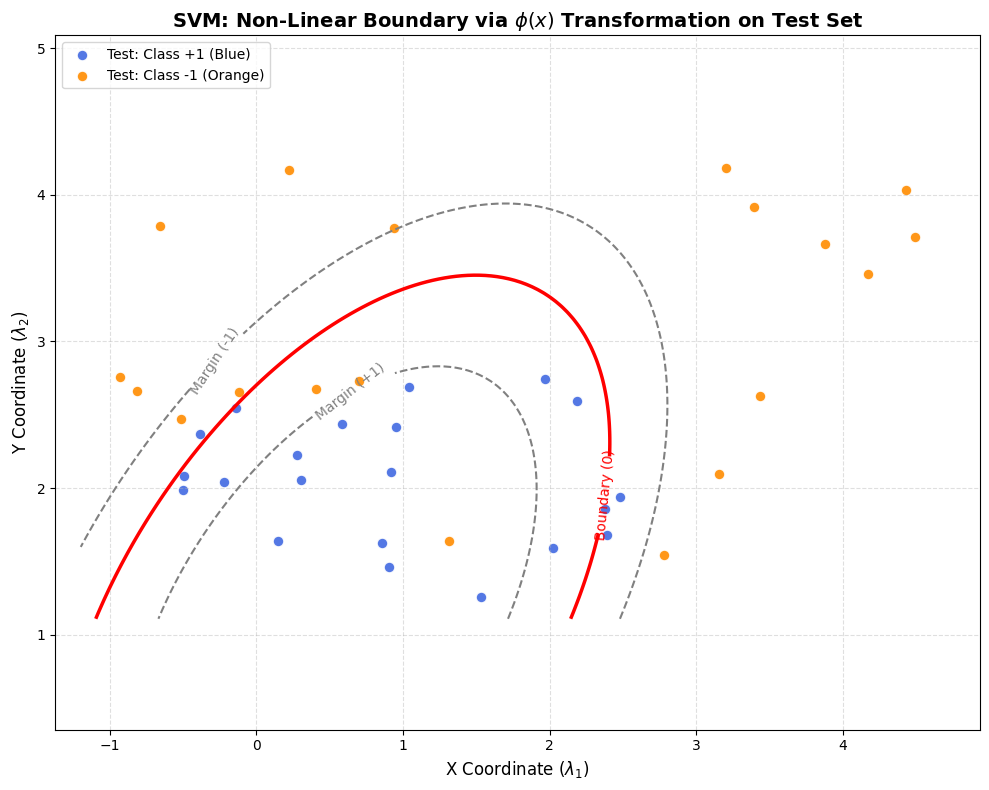

In [19]:
from sklearn.model_selection import train_test_split

#--------------------------------------------------------------
# 2. TARGET AND DATASET PREPARATION
#--------------------------------------------------------------
# Você já tem X (200, 2) e y_labels (200,) definidos no começo.
# Basta passar eles direto para o train_test_split:

X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.20, random_state=42)

#--------------------------------------------------------------
# 3. KERNEL TRICK MANUAL (5D Mapping)
#--------------------------------------------------------------

# Basis transformation
def phi(x_vec):
    """ Maps [x, y] to a 5D space where quadratic terms become linear """
    x, y = x_vec[0], x_vec[1]
    return np.array([x, y, x**2, y**2, x*y])

def f(x_vec, w, b):
    """
    Represents f(x; w, b) = w · phi(x) + b
    x_vec: observation vector [x, y]
    w: weights found by the SVM [w1, w2, w3, w4, w5]
    b: bias (intercept)
    """
    return np.dot(w, phi(x_vec)) + b

#--------------------------------------------------------------
# Training, learning w and b
#--------------------------------------------------------------

# Transforming the original 2D training data to the 5D feature space
X_train_phi = np.array([phi(xi) for xi in X_train])

# 1. Creating and training the model (using linear kernel in 5D space)
clf_linear = SVC(kernel='linear', C=1.0)
clf_linear.fit(X_train_phi, y_train)

# 2. Extracting optimized parameters
# w (5 components) is in coef_[0], bias b is in intercept_[0]
w = clf_linear.coef_[0]
b = clf_linear.intercept_[0]

print(f"Weights in 5D space (w): {w}")
print(f"Bias (b): {b:.4f}")

#--------------------------------------------------------------
# 4. FIGURES: VISUALIZATION OF NON-LINEAR BOUNDARY
#--------------------------------------------------------------

# Graph generator using the TEST set
plt.figure(figsize=(10, 8))

# Plotting test points (unseen data)
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1],
            c='royalblue', label='Test: Class +1 (Blue)', edgecolors='w', alpha=0.9, s=60)
plt.scatter(X_test[y_test==-1][:,0], X_test[y_test==-1][:,1],
            c='darkorange', label='Test: Class -1 (Orange)', edgecolors='w', alpha=0.9, s=60)

# Creating the meshgrid to map the decision boundary f(x) = 0
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 150), np.linspace(ylim[0], ylim[1], 150))

# Calculating f for each point in the meshgrid projected in 5D space
Z = np.array([f(np.array([px, py]), w, b) for px, py in zip(np.ravel(xx), np.ravel(yy))])
Z = Z.reshape(xx.shape)

# Drawing the non-linear decision boundary (f=0) and support margins (f=1, f=-1)
contour = plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['gray', 'red', 'gray'],
                      linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])
plt.clabel(contour, inline=True, fontsize=10, fmt={-1:'Margin (-1)', 0:'Boundary (0)', 1:'Margin (+1)'})

# Graph aesthetics
plt.title('SVM: Non-Linear Boundary via $\phi(x)$ Transformation on Test Set', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate ($\lambda_1$)', fontsize=12)
plt.ylabel('Y Coordinate ($\lambda_2$)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.axis('equal')
plt.tight_layout()

# Saving the figure in the project folder
plt.savefig('svm_kernel_boundary.png', dpi=300)

#--------------------------------------------------------------
# 5. MODEL EVALUATION METRICS
#--------------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Transform the 2D test data into the 5D feature space using phi
X_test_phi = np.array([phi(xi) for xi in X_test])

# 2. Make predictions on the unseen test set
y_pred = clf_linear.predict(X_test_phi)

# 3. Calculate classification metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# 4. Print the formatted results
print("\n" + "="*60)
print("             SVM EVALUATION METRICS (TEST SET)")
print("="*60)
print(f"1. Accuracy:  {acc:.4f}  (Overall correctness of the model)")
print(f"2. Precision: {prec:.4f}  (True Positives / Predicted Positives)")
print(f"3. Recall:    {rec:.4f}  (True Positives / Actual Positives)")
print(f"4. F1-Score:  {f1:.4f}  (Harmonic mean of Precision and Recall)")
print("-" * 60)
print("5. Confusion Matrix:")
print(f"   [{cm[0][0]:2d}  {cm[0][1]:2d}]  <-- Actual Class -1 (Orange)")
print(f"   [{cm[1][0]:2d}  {cm[1][1]:2d}]  <-- Actual Class +1 (Blue)")
print("     ^   ^")
print("     |   |")
print("     |   Predicted Class +1")
print("Predicted Class -1")
print("="*60 + "\n")

## Conclusão e Próximos Passos

Este repositório documenta uma imersão completa no funcionamento interno das **Support Vector Machines (SVM)**, indo muito além da simples importação de bibliotecas padrão de mercado.

Ao longo desta implementação, pudemos provar conceitos matemáticos fundamentais na prática:

1. **A Mecânica da Otimização:** Demonstramos como o hiperplano linear é construído passo a passo através da minimização da *Hinge Loss*, utilizando o Gradiente Descendente Estocástico (SGD) "do zero".
2. **Escalabilidade Multiclasse:** Vimos como a estratégia *One-vs-Rest* (OvR) permite que um classificador essencialmente binário resolva problemas complexos e de alta dimensionalidade (784 features), atingindo excelentes métricas no dataset MNIST.
3. **A Geometria do Kernel Trick:** O ponto alto do estudo foi a construção explícita da função de mapeamento $\phi(\vec{x})$, provando visualmente e algebricamente como um hiperplano perfeitamente plano em um espaço de 5 dimensões se projeta como uma fronteira elíptica complexa no espaço 2D original.

### Explorando Novos Horizontes

Com a base geométrica e matemática do SVM consolidada, os próximos passos naturais para evolução estrutural deste repositório e estudos futuros incluem:

* **Regressão de Vetores de Suporte (SVR):** Inverter a lógica da *Soft Margin* para criar um "tubo" de tolerância ($\epsilon$-tube), utilizando a mecânica dos vetores de suporte para prever valores contínuos em vez de classes discretas.
* **Otimização de Hiperparâmetros:** Implementar técnicas de *Grid Search* ou Otimização Bayesiana para encontrar o balanço perfeito entre a regularização ($C$) e a complexidade não linear ($\gamma$) em bases de dados ruidosas do mundo real.

A compreensão profunda da álgebra por trás das fronteiras de decisão do SVM é o que diferencia um modelador de dados de um verdadeiro Cientista de Dados. Sinta-se à vontade para clonar este projeto e experimentar diferentes bases e graus polinomiais no mapeamento $\phi(\vec{x})$!